# Example set - Builders Temeplate include

In [17]:
# ===== Shared setup: every example cell depends on this one, run it first =====
import numpy as np
import matplotlib.pyplot as plt

from admiser import OCPSolver

# There is exactly one solve entry point: OCPSolver(problem).solve(...)
# Whether that is a single solve or an eps -> 0 continuation, and the number of
# rounds and shrink ratio, are declared in the PROBLEM DEFINITION FILE:
#     problem.set_transcription(mode="continuation", n_rounds=4, shrink=0.1)
# Nothing here has to branch on it, and the result dictionary has the same shape
# either way (the "rounds" field simply has length 1 in single mode).


def solve_modes(EX, modes=("single", "continuation"), **solve_kw):
    """
    Solve the same problem once per requested mode, for comparison.

    The mode parameters (n_rounds / shrink) are taken from the set_transcription()
    call in the problem file; only `mode` is overridden here, and the original
    setting is restored afterwards. solve() never mutates the problem, so calling
    it repeatedly is safe.
    """
    p = EX.problem
    default = dict(p.transcription)
    out = {}
    try:
        for m in modes:
            cfg = dict(default); cfg["mode"] = m
            p.set_transcription(**cfg)
            print(f"\n########## mode: {m} ##########")
            out[m] = OCPSolver(p).solve(**solve_kw)
    finally:
        p.set_transcription(**default)
    return out


def report_result(tag, res):
    """
    Print the results of one mode; for a multi-round solve, list eps/gamma and the
    true violation for every round.
    """
    r = res["scipy_result"]
    print(f"\n=== {tag} ===")
    print(f"J*     = {res['J_opt']}")
    print(f"status = {r.status}  ({r.message})")
    if res.get("theta_opt") is not None:
        print(f"theta* = {res['theta_opt']}")
    if res.get("eq_resid") is not None:
        print(f"max|eq|  = {np.max(np.abs(res['eq_resid'])):.3e}   (should be ~ 0)")
    if res.get("ineq_resid") is not None:
        print(f"min ineq = {np.min(res['ineq_resid']):.3e}   (should be >= 0)")
    if res.get("path_viol") is not None:
        print(f"max h(t) = {np.max(res['path_viol']):+.3e}   (true violation of the original constraint, should be <= 0)")
    if len(res.get("rounds", [])) > 1:
        print("  per round:")
        for i, hh in enumerate(res["rounds"]):
            print(f"    [{i+1}] eps={min(hh['eps']):.1e}  gamma={min(hh['gamma']):.3e}  "
                  f"J={hh['J_opt']:+.10g}  max h(t)={hh['max_path_viol']:+.3e}  "
                  f"status={hh['status']}  nit={hh['nit']}")


#: How the two modes are told apart in the plots: solid = single, dashed = continuation
STYLE = {"single": dict(ls="-", lw=1.6, alpha=1.0),
         "continuation": dict(ls="--", lw=1.6, alpha=0.9)}


## No system parameters, pure OCP

Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.185953065753833
            Iterations: 43
            Function evaluations: 46
            Gradient evaluations: 43

=== report ===
theta_opt: None
J*: 6.185953065753833
equality constraint residual (includes ∫L·dt terms):
[-5.44441319e-11  6.10513379e-11 -6.02149624e-15 -8.00545394e-12
  8.76321122e-12 -4.94396191e-16]


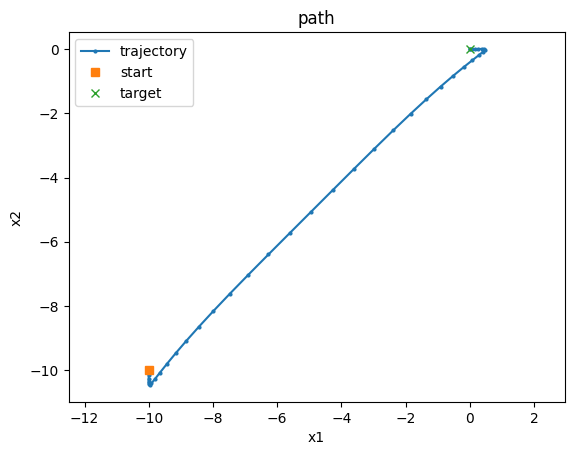

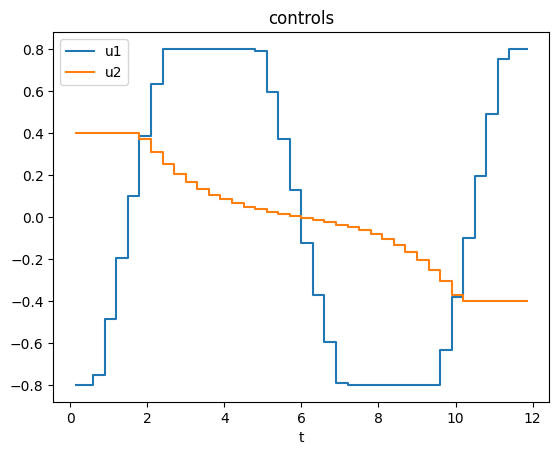

In [18]:
# solve_my_robot_with_param.py
from admiser.examples.my_robot_problem import problem, N, dt, x0, xT

def main():
    solver = OCPSolver(problem)
    result = solver.solve(maxiter=500, ftol=1e-9, disp=True)

    U_opt     = result["U_opt"]
    theta_opt = result["theta_opt"]
    X_opt     = result["X_opt"]
    t_opt     = result["t_opt"]
    J_opt     = result["J_opt"]
    eq_err  = result["eq_resid"]      # equality residual G(z), should be ~ 0
    ineq_err= result["ineq_resid"]    # inequality residual C(z), should be >= 0

    print("\n=== report ===")
    print("theta_opt:", theta_opt)
    print("J*:", J_opt)
    if eq_err is not None:
        print("equality constraint residual (includes ∫L·dt terms):")
        print(eq_err)
    if ineq_err is not None:
        print("inequality constraint residual (includes ∫L·dt terms):")
        print(ineq_err)

    # state trajectories
    plt.figure()
    plt.plot(X_opt[:,0], X_opt[:,1], '-o', ms=2, label='trajectory')
    plt.plot(x0[0], x0[1], 's', label='start'); plt.plot(xT[0], xT[1], 'x', label='target')
    plt.axis('equal'); plt.legend(); plt.title('path'); plt.xlabel('x1'); plt.ylabel('x2')

    # controls
    U = U_opt.reshape(N, 2)
    tc = np.linspace(0.0, N*dt, N, endpoint=False) + 0.5*dt
    plt.figure(); plt.step(tc, U[:,0], where='mid', label='u1'); plt.step(tc, U[:,1], where='mid', label='u2')
    plt.legend(); plt.title('controls'); plt.xlabel('t')

    plt.show()

if __name__ == "__main__":
    main()


## Pure OCP - initial guess sensitive

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.3534320535208112
            Iterations: 248
            Function evaluations: 249
            Gradient evaluations: 248

=== results ===
J* = -0.3534320535208112


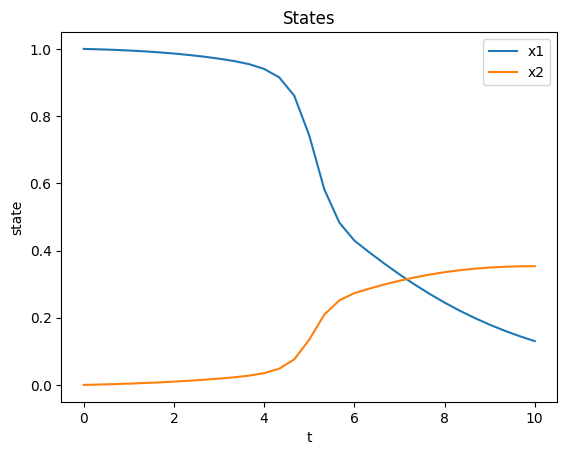

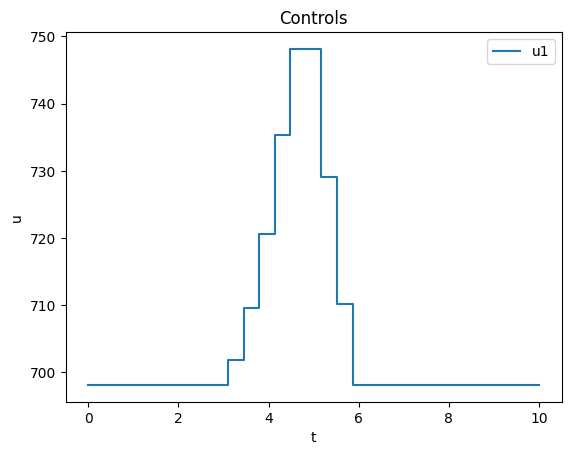

In [19]:
# solve_my_ocp_problem_tpl.py
from admiser.examples.my_bitumen_pyrolysis import problem, N, dt

def main():
    solver = OCPSolver(problem)
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt  = res["U_opt"]              # shape = (N*nu,)
    theta  = res.get("theta_opt", None)
    J_opt  = res["J_opt"]
    X_opt  = res["X_opt"]              # shape = (N+1, nx)
    t_opt  = res["t_opt"]              # shape = (N+1,)
    eq_res = res.get("eq_resid", None)   # equality residual G(z), should be ~ 0
    in_res = res.get("ineq_resid", None) # inequality residual C(z), should be >= 0

    print("\n=== results ===")
    print("J* =", J_opt)
    if theta is not None:
        print("theta* =", theta)
    if eq_res is not None:
        print("eq residual:", eq_res)
    if in_res is not None:
        print("ineq residual:", in_res)

    # states
    plt.figure()
    for i in range(X_opt.shape[1]):
        plt.plot(t_opt, X_opt[:, i], label=f"x{i+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend()

    # controls: piecewise constant over N segments; reshape the flat U_opt
    nu = problem.nu
    U_mat = U_opt.reshape(N, nu) if U_opt.ndim == 1 else U_opt
    tc = np.linspace(0.0, np.sum(np.diff(t_opt)), N)  # equals linspace(0, T, N) for constant dt
    plt.figure()
    for j in range(nu):
        plt.step(tc, U_mat[:, j], where='pre', label=f"u{j+1}")
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


# System parameters are included

## Feedback control

Optimization terminated successfully    (Exit mode 0)
            Current function value: 23.494869150545266
            Iterations: 17
            Function evaluations: 17
            Gradient evaluations: 17

=== report ===
theta_opt [z1,z2,z3,z4] = [-10.         -10.          -2.50056906   2.17907382]
J* = 23.494869150545266


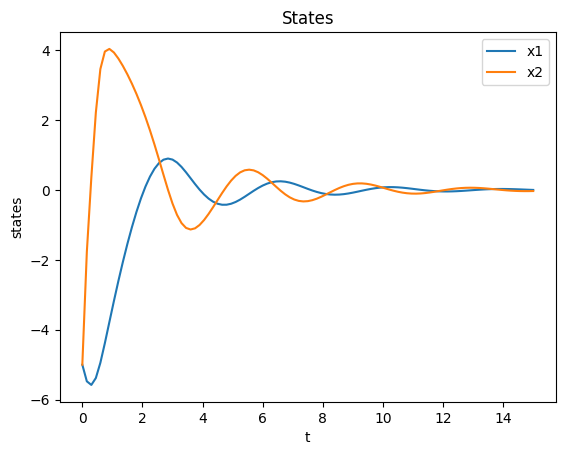

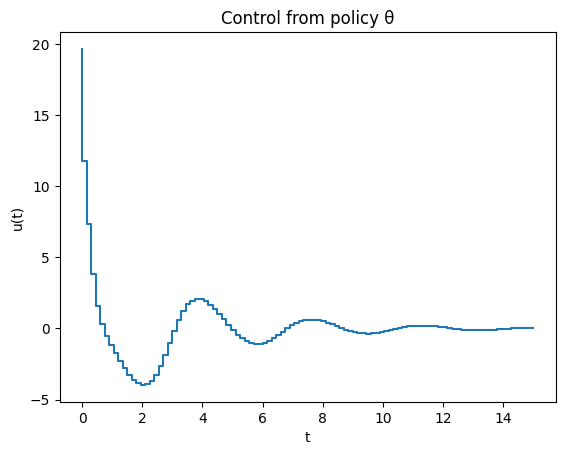

In [20]:
from admiser.examples.my_policy_param_problem import problem, N, dt, policy_u

def main():
    solver = OCPSolver(problem)
    result = solver.solve(maxiter=600, ftol=1e-9, disp=True)

    U_opt     = result["U_opt"]        # length 0 here, since nu = 0
    theta_opt = result["theta_opt"]    # optimal [z1..z4]
    X_opt     = result["X_opt"]
    t_opt     = result["t_opt"]
    J_opt     = result["J_opt"]

    print("\n=== report ===")
    print("theta_opt [z1,z2,z3,z4] =", theta_opt)
    print("J* =", J_opt)

    # reconstruct the u(t) trajectory from the optimal theta, for plotting
    U_series = np.array([ float(policy_u(x, theta_opt)) for x in X_opt ])

    # states
    plt.figure()
    plt.plot(t_opt, X_opt[:,0], label='x1')
    plt.plot(t_opt, X_opt[:,1], label='x2')
    plt.xlabel('t'); plt.ylabel('states'); plt.title('States'); plt.legend()

    # controls (left endpoint of each segment)
    tc = np.linspace(0.0, N*dt, N+1)
    plt.figure()
    plt.step(tc, U_series, where='pre')
    plt.xlabel('t'); plt.ylabel('u(t)'); plt.title('Control from policy θ')

    plt.show()

if __name__ == "__main__":
    main()

## Recursive control

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.5759369967459305
            Iterations: 184
            Function evaluations: 185
            Gradient evaluations: 184

=== optimal solution (key quantities) ===
zeta1 = 0.030520,  zeta2 = 0.575937   (the objective is -zeta2 = -0.575936997)
J* = -0.575936997
u_max = 6.0


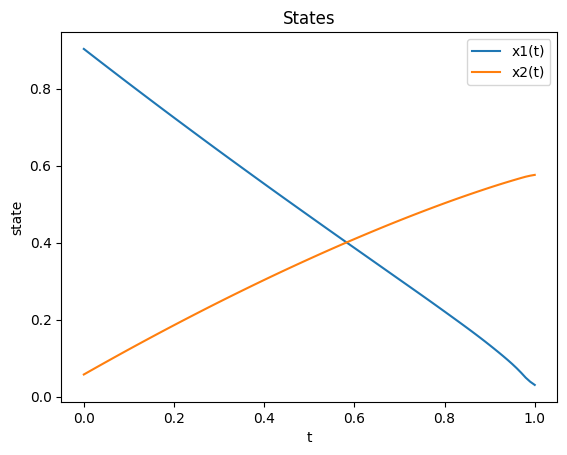

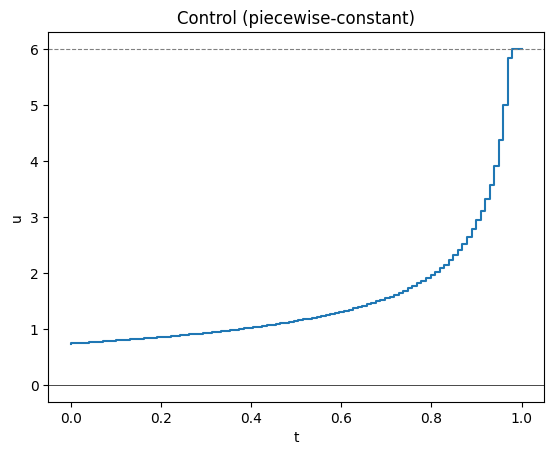

In [21]:
# solve_ex_882_theta_zeta.py
from admiser.examples.my_ex_882_zeta_param import problem, N, dt, u_max

def main():
    solver = OCPSolver(problem)
    # two equality constraints, solved with SLSQP
    res = solver.solve(maxiter=800, ftol=1e-9, disp=True)

    U_opt     = res["U_opt"]        # shape=(N,)
    theta_opt = res["theta_opt"]    # [ζ1, ζ2]
    J_opt     = res["J_opt"]
    X_opt     = res["X_opt"]
    t_opt     = res["t_opt"]

    z1, z2 = theta_opt
    print("\n=== optimal solution (key quantities) ===")
    print(f"zeta1 = {z1:.6f},  zeta2 = {z2:.6f}   (the objective is -zeta2 = {-z2:.9f})")
    print(f"J* = {J_opt:.9f}")
    print(f"u_max = {u_max}")

    plt.figure()
    plt.plot(t_opt, X_opt[:,0], label='x1(t)')
    plt.plot(t_opt, X_opt[:,1], label='x2(t)')
    plt.xlabel('t'); plt.ylabel('state'); plt.title('States'); plt.legend()

    tc = np.linspace(0.0, N*dt, N)
    plt.figure()
    plt.step(tc, U_opt, where='pre')
    plt.axhline(0.0, color='k', lw=0.5)
    plt.axhline(u_max, color='gray', ls='--', lw=0.8)
    plt.xlabel('t'); plt.ylabel('u'); plt.title('Control (piecewise-constant)')

    plt.show()

if __name__ == "__main__":
    main()


# Continuous state and control inequality constraints

## Simple example - continuous state inequality


########## mode: single ##########

########## mode: continuation ##########
[ADMISER] 第 1/4 轮  eps=1.000e-01  J=+0.14636838  max h(t)=+7.975e-02  status=0  nit=95
[ADMISER] 第 2/4 轮  eps=1.000e-02  J=+0.167629  max h(t)=+7.649e-03  status=0  nit=106
[ADMISER] 第 3/4 轮  eps=1.000e-03  J=+0.1700801  max h(t)=+1.144e-05  status=0  nit=131
[ADMISER] 第 4/4 轮  eps=1.000e-04  J=+0.17042904  max h(t)=-5.965e-04  status=0  nit=107

=== single ===
J*     = 0.17042903635360074
status = 0  (Optimization terminated successfully)
min ineq = -1.511e-13   (should be >= 0)
max h(t) = -5.967e-04   (true violation of the original constraint, should be <= 0)

=== continuation ===
J*     = 0.17042903670050316
status = 0  (Optimization terminated successfully)
min ineq = -3.466e-14   (should be >= 0)
max h(t) = -5.965e-04   (true violation of the original constraint, should be <= 0)
  per round:
    [1] eps=1.0e-01  gamma=2.500e-02  J=+0.1463683779  max h(t)=+7.975e-02  status=0  nit=95
    [2] eps=1.0e-02 

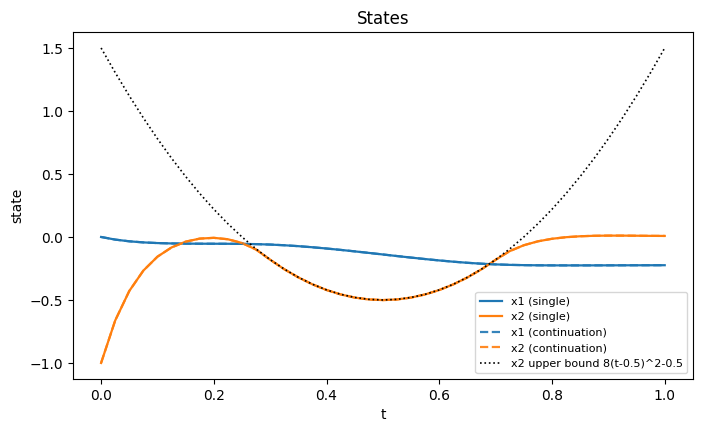

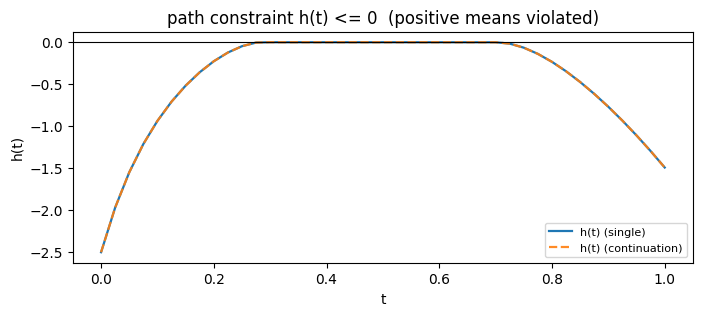

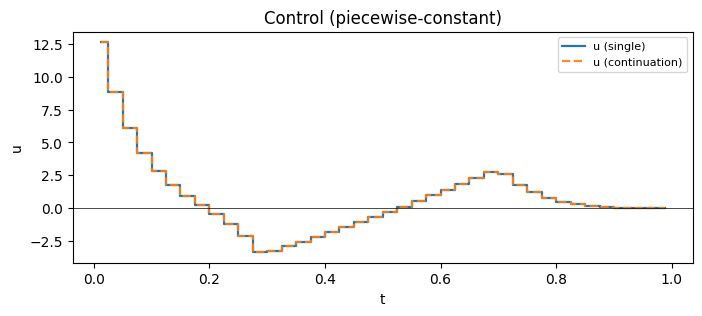

In [22]:
# solve_state_constrained.py
from admiser.examples import my_state_constrained_problem as EX
N, dt, T = EX.N, EX.dt, EX.T

# The solve mode is declared in my_state_constrained_problem.py; list here the
# modes you want to compare. To run only the one the problem file declares, use
# MODES = (EX.problem.transcription["mode"],)
MODES = ("single", "continuation")


def main(modes=MODES):
    results = solve_modes(EX, modes, maxiter=1000, ftol=1e-12)
    for tag, res in results.items():
        report_result(tag, res)

    # ---- state trajectories: colour by state component, line style by solve mode ----
    plt.figure(figsize=(8, 4.5))
    for tag, res in results.items():
        for i, name in enumerate(("x1", "x2")):
            plt.plot(res["t_opt"], res["X_opt"][:, i], color=f"C{i}",
                     label=f"{name} ({tag})", **STYLE[tag])
    t_ref = next(iter(results.values()))["t_opt"]
    plt.plot(t_ref, 8.0 * (t_ref - 0.5) ** 2 - 0.5, "k:", lw=1.2,
             label="x2 upper bound 8(t-0.5)^2-0.5")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend(fontsize=8)

    # ---- true violation of the path constraint ----
    plt.figure(figsize=(8, 3))
    for tag, res in results.items():
        t_, X_ = res["t_opt"], res["X_opt"]
        h_ = [EX.hfun(t_[k], X_[k], None, None) for k in range(len(t_))]
        plt.plot(t_, h_, label=f"h(t) ({tag})", **STYLE[tag])
    plt.axhline(0.0, color="k", lw=0.8)
    plt.xlabel("t"); plt.ylabel("h(t)"); plt.title("path constraint h(t) <= 0  (positive means violated)")
    plt.legend(fontsize=8)

    # ---- controls (piecewise constant) ----
    tc = np.linspace(0.0, N * dt, N, endpoint=False) + 0.5 * dt
    plt.figure(figsize=(8, 3))
    for tag, res in results.items():
        plt.step(tc, res["U_opt"], where="mid", label=f"u ({tag})", **STYLE[tag])
    plt.axhline(0.0, color="k", lw=0.5)
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Control (piecewise-constant)")
    plt.legend(fontsize=8)

    plt.show()


if __name__ == "__main__":
    main()


## Continuous state and control constraint


########## mode: single ##########

########## mode: continuation ##########
[ADMISER] 第 1/4 轮  eps=1.000e+00  J=+32.584233  max h(t)=+3.321e+00  status=0  nit=21
[ADMISER] 第 2/4 轮  eps=1.000e-01  J=+42.616192  max h(t)=+4.696e-01  status=0  nit=41
[ADMISER] 第 3/4 轮  eps=1.000e-02  J=+44.741211  max h(t)=+1.022e-01  status=0  nit=44
[ADMISER] 第 4/4 轮  eps=1.000e-03  J=+45.285908  max h(t)=+3.395e-02  status=0  nit=55

=== single ===
J*     = 45.28590750823808
status = 0  (Optimization terminated successfully)
min ineq = -1.184e-12   (should be >= 0)
max h(t) = +3.395e-02   (true violation of the original constraint, should be <= 0)

=== continuation ===
J*     = 45.285907507944486
status = 0  (Optimization terminated successfully)
min ineq = -2.594e-12   (should be >= 0)
max h(t) = +3.395e-02   (true violation of the original constraint, should be <= 0)
  per round:
    [1] eps=1.0e+00  gamma=1.125e+00  J=+32.5842333  max h(t)=+3.321e+00  status=0  nit=21
    [2] eps=1.0e-01  gamma=1.

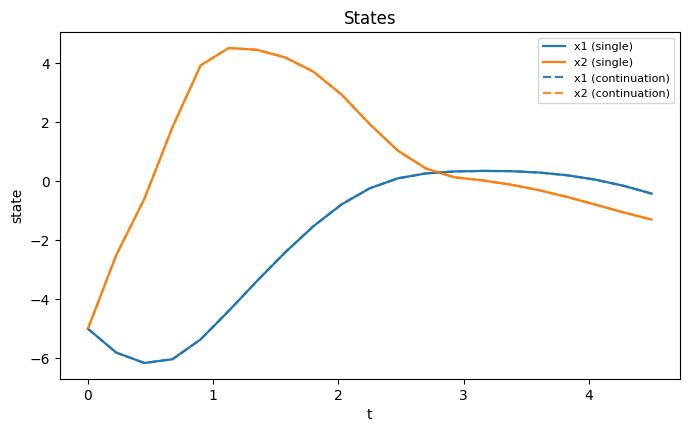

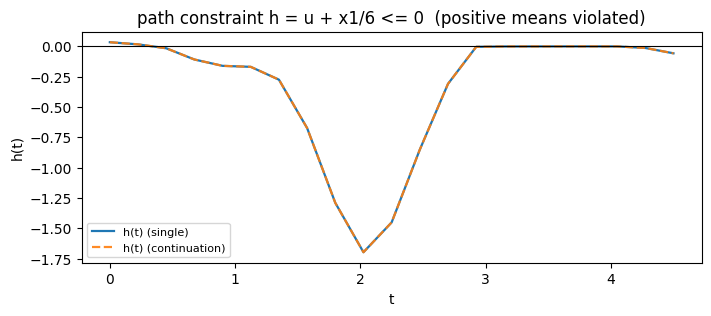

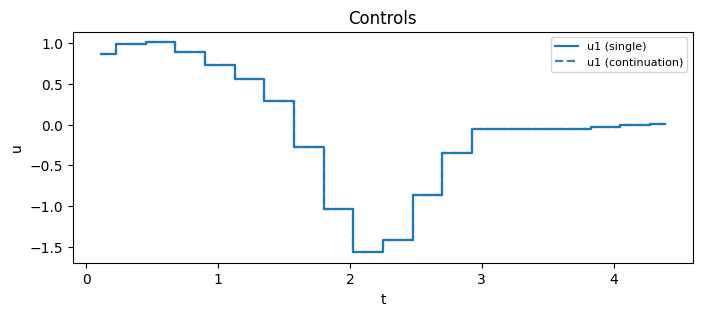

In [23]:
# solve_state_control_constraint.py
from admiser.examples import my_state_control_constraint as EX
N, dt, T = EX.N, EX.dt, EX.T

MODES = ("single", "continuation")


def main(modes=MODES):
    results = solve_modes(EX, modes, maxiter=2000, ftol=1e-9)
    for tag, res in results.items():
        report_result(tag, res)

    nu = EX.problem.nu

    # ---- states ----
    plt.figure(figsize=(8, 4.5))
    for tag, res in results.items():
        for i in range(res["X_opt"].shape[1]):
            plt.plot(res["t_opt"], res["X_opt"][:, i], color=f"C{i}",
                     label=f"x{i+1} ({tag})", **STYLE[tag])
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend(fontsize=8)

    # ---- true violation of the mixed state-control constraint h = u + x1/6 <= 0 ----
    plt.figure(figsize=(8, 3))
    for tag, res in results.items():
        t_, X_ = res["t_opt"], res["X_opt"]
        U_ = res["U_opt"].reshape(N, nu)
        h_ = [EX.h(t_[k], X_[k], U_[min(k, N - 1)], None) for k in range(len(t_))]
        plt.plot(t_, h_, label=f"h(t) ({tag})", **STYLE[tag])
    plt.axhline(0.0, color="k", lw=0.8)
    plt.xlabel("t"); plt.ylabel("h(t)"); plt.title("path constraint h = u + x1/6 <= 0  (positive means violated)")
    plt.legend(fontsize=8)

    # ---- controls (piecewise constant) ----
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5 * dt
    plt.figure(figsize=(8, 3))
    for tag, res in results.items():
        U_mat = res["U_opt"].reshape(N, nu)
        for j in range(nu):
            plt.step(tc, U_mat[:, j], where="mid", color=f"C{j}",
                     label=f"u{j+1} ({tag})", **STYLE[tag])
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend(fontsize=8)

    plt.show()


if __name__ == "__main__":
    main()


## More commplicate problem - kobe port


########## mode: single ##########

########## mode: continuation ##########
[ADMISER] 第 1/3 轮  eps=1.000e+00  J=+0.0052589534  max h(t)=+1.021e-01  status=0  nit=79
[ADMISER] 第 2/3 轮  eps=1.000e-01  J=+0.0052589534  max h(t)=+1.021e-01  status=0  nit=1
[ADMISER] 第 3/3 轮  eps=1.000e-02  J=+0.0052630367  max h(t)=+3.144e-02  status=0  nit=9

=== single ===
J*     = 0.005255439182895264
status = 0  (Optimization terminated successfully)
max|eq|  = 5.336e-10   (should be ~ 0)
min ineq = -7.793e-09   (should be >= 0)
max h(t) = +5.559e-02   (true violation of the original constraint, should be <= 0)

=== continuation ===
J*     = 0.005263036695274005
status = 0  (Optimization terminated successfully)
max|eq|  = 4.475e-11   (should be ~ 0)
min ineq = -1.552e-09   (should be >= 0)
max h(t) = +3.144e-02   (true violation of the original constraint, should be <= 0)
  per round:
    [1] eps=1.0e+00  gamma=2.500e-01  J=+0.005258953418  max h(t)=+1.021e-01  status=0  nit=79
    [2] eps=1.0e-01  

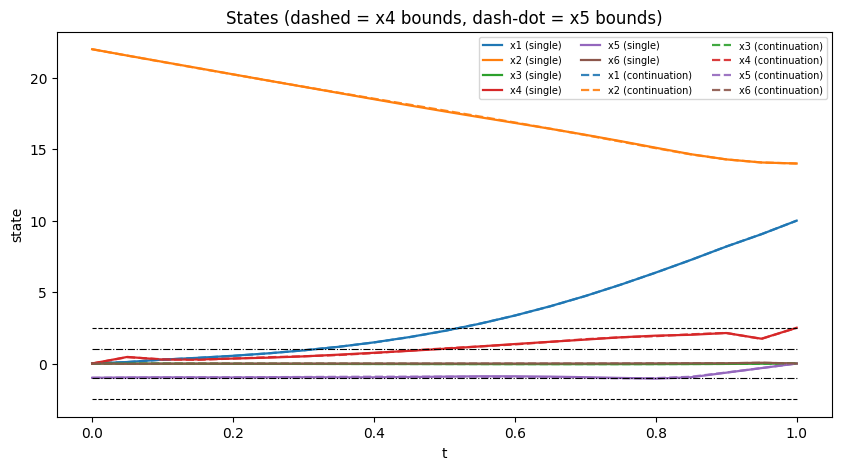

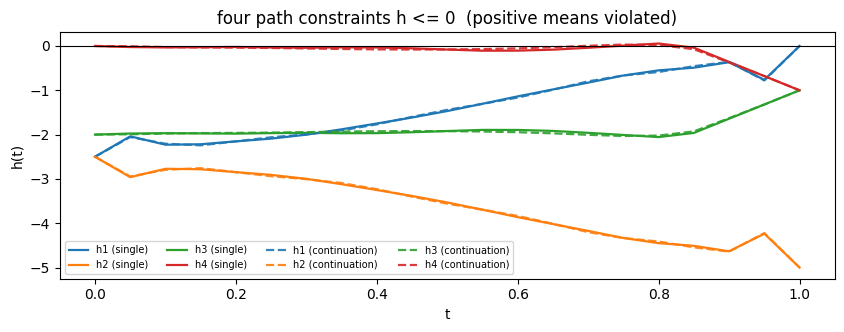

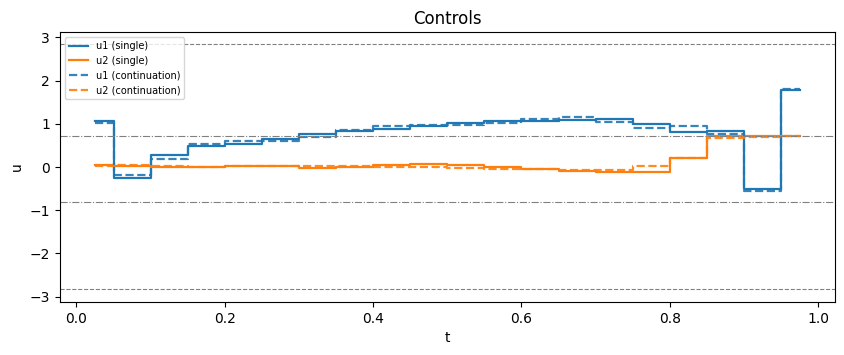

In [24]:
# solve_six_state.py (port_kobe)
from admiser.examples import my_port_kobe as EX
T, N, dt = EX.T, EX.N, EX.dt

MODES = ("single", "continuation")


def main(modes=MODES):
    results = solve_modes(EX, modes, maxiter=2000, ftol=1e-8)
    for tag, res in results.items():
        report_result(tag, res)

    # ---- states ----
    plt.figure(figsize=(10, 5))
    for tag, res in results.items():
        for i in range(6):
            plt.plot(res["t_opt"], res["X_opt"][:, i], color=f"C{i}",
                     label=f"x{i+1} ({tag})", **STYLE[tag])
    t_ref = next(iter(results.values()))["t_opt"]
    for lvl, ls in ((2.5, "k--"), (-2.5, "k--"), (1.0, "k-."), (-1.0, "k-.")):
        plt.plot(t_ref, lvl * np.ones_like(t_ref), ls, lw=0.8)
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States (dashed = x4 bounds, dash-dot = x5 bounds)")
    plt.legend(ncol=3, fontsize=7)

    # ---- true violation of the four path constraints ----
    plt.figure(figsize=(10, 3.2))
    for tag, res in results.items():
        t_, X_ = res["t_opt"], res["X_opt"]
        for j, hf in enumerate(EX.PATH_INEQS):
            h_ = [hf(t_[k], X_[k], None, None) for k in range(len(t_))]
            plt.plot(t_, h_, color=f"C{j}", label=f"h{j+1} ({tag})", **STYLE[tag])
    plt.axhline(0.0, color="k", lw=0.8)
    plt.xlabel("t"); plt.ylabel("h(t)"); plt.title("four path constraints h <= 0  (positive means violated)")
    plt.legend(ncol=4, fontsize=7)

    # ---- controls (piecewise constant) ----
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5 * dt
    plt.figure(figsize=(10, 3.5))
    for tag, res in results.items():
        U = res["U_opt"].reshape(N, 2)
        plt.step(tc, U[:, 0], where="mid", color="C0", label=f"u1 ({tag})", **STYLE[tag])
        plt.step(tc, U[:, 1], where="mid", color="C1", label=f"u2 ({tag})", **STYLE[tag])
    for lvl, ls in ((2.83374, "--"), (-2.83374, "--"), (0.71265, "-."), (-0.80865, "-.")):
        plt.axhline(lvl, color="gray", ls=ls, lw=0.8)
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend(fontsize=7)

    plt.show()


if __name__ == "__main__":
    main()


## Optimal Euler buckling beam - continuous inequality and system parameters


########## mode: single ##########

########## mode: continuation ##########
[ADMISER] 第 1/5 轮  eps=1.000e-02  J=-12.822079  max h(t)=+9.491e-02  status=0  nit=91
[ADMISER] 第 2/5 轮  eps=1.000e-03  J=-12.771396  max h(t)=+8.990e-03  status=0  nit=60
[ADMISER] 第 3/5 轮  eps=1.000e-04  J=-12.766202  max h(t)=+8.934e-04  status=0  nit=50
[ADMISER] 第 4/5 轮  eps=1.000e-05  J=-12.765681  max h(t)=+8.951e-05  status=0  nit=22
[ADMISER] 第 5/5 轮  eps=1.000e-06  J=-12.765629  max h(t)=+9.097e-06  status=0  nit=10

=== single ===
J*     = -12.765628088881973
status = 0  (Optimization terminated successfully)
theta* = [12.76562809  0.5       ]
max|eq|  = 6.342e-11   (should be ~ 0)
min ineq = -2.492e-11   (should be >= 0)
max h(t) = +8.421e-06   (true violation of the original constraint, should be <= 0)
  z1* = 12.765628,  z2* = 0.500000

=== continuation ===
J*     = -12.76562927244803
status = 0  (Optimization terminated successfully)
theta* = [12.76562927  0.5       ]
max|eq|  = 7.586e-13   (sh

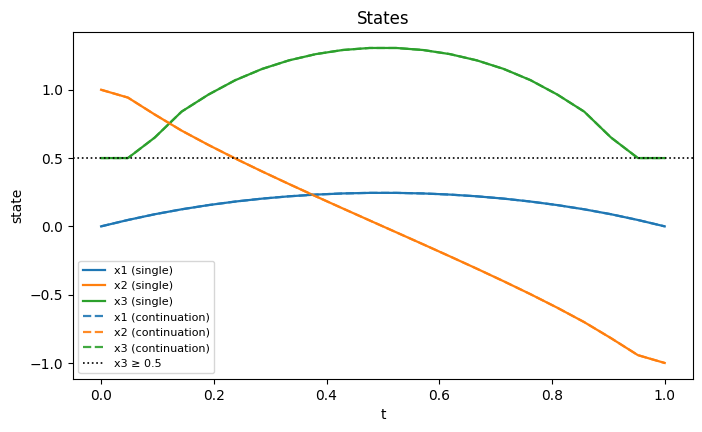

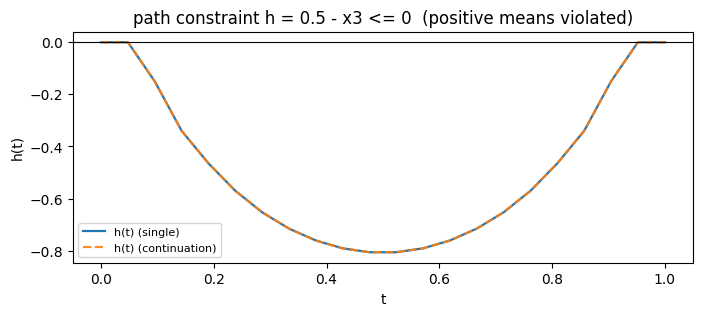

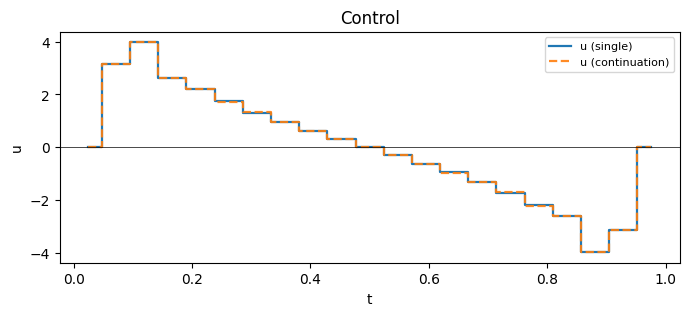

In [25]:
# solve_z1z2_problem.py (euler buckling beam)
from admiser.examples import my_euler_buckling_beam as EX
T, N, dt = EX.T, EX.N, EX.dt

MODES = ("single", "continuation")


def main(modes=MODES):
    results = solve_modes(EX, modes, maxiter=2000, ftol=1e-9)
    for tag, res in results.items():
        report_result(tag, res)
        z1, z2 = res["theta_opt"]
        print(f"  z1* = {z1:.6f},  z2* = {z2:.6f}")

    # ---- states ----
    plt.figure(figsize=(8, 4.5))
    for tag, res in results.items():
        for i in range(3):
            plt.plot(res["t_opt"], res["X_opt"][:, i], color=f"C{i}",
                     label=f"x{i+1} ({tag})", **STYLE[tag])
    plt.axhline(0.5, color="k", ls=":", lw=1.2, label="x3 ≥ 0.5")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend(fontsize=8)

    # ---- true violation of the path constraint h = 0.5 - x3 <= 0 ----
    plt.figure(figsize=(8, 3))
    for tag, res in results.items():
        t_, X_ = res["t_opt"], res["X_opt"]
        h_ = [EX.hfun(t_[k], X_[k], None, None) for k in range(len(t_))]
        plt.plot(t_, h_, label=f"h(t) ({tag})", **STYLE[tag])
    plt.axhline(0.0, color="k", lw=0.8)
    plt.xlabel("t"); plt.ylabel("h(t)"); plt.title("path constraint h = 0.5 - x3 <= 0  (positive means violated)")
    plt.legend(fontsize=8)

    # ---- controls (piecewise constant) ----
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5 * dt
    plt.figure(figsize=(8, 3))
    for tag, res in results.items():
        plt.step(tc, res["U_opt"], where="mid", label=f"u ({tag})", **STYLE[tag])
    plt.axhline(0.0, color="k", lw=0.5)
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Control"); plt.legend(fontsize=8)

    plt.show()


if __name__ == "__main__":
    main()


# Bang-bang control

Optimization terminated successfully    (Exit mode 0)
            Current function value: -41.30115538278415
            Iterations: 65
            Function evaluations: 65
            Gradient evaluations: 65

=== results ===
J* = -41.30115538278415


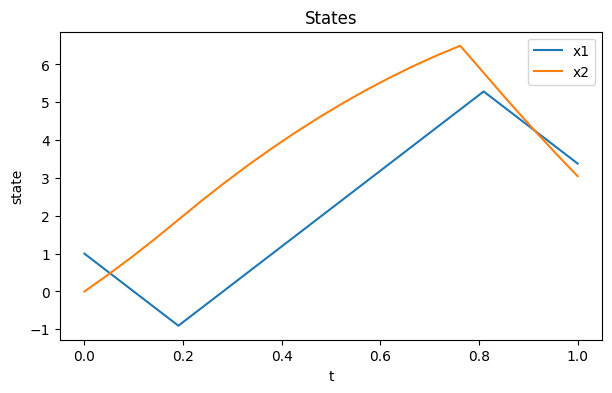

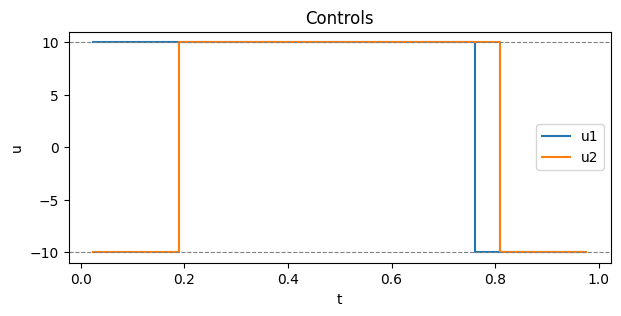

In [26]:
# solve_lin2x2.py
from admiser.examples.my_bang_bang import problem, T, N, dt

def main():
    solver = OCPSolver(problem)
    res = solver.solve(maxiter=2000, ftol=1e-8, disp=True)

    U_opt    = res["U_opt"]         # shape = (2N,)
    X_opt    = res["X_opt"]         # shape = (N+1, 2)
    t_opt    = res["t_opt"]

    print("\n=== results ===")
    print("J* =", res["J_opt"])
    if res["eq_resid"]   is not None: print("eq residual:",   res["eq_resid"])
    if res["ineq_resid"] is not None: print("ineq residual:", res["ineq_resid"])

    # state trajectories
    plt.figure(figsize=(7,4))
    plt.plot(t_opt, X_opt[:,0], label='x1')
    plt.plot(t_opt, X_opt[:,1], label='x2')
    plt.xlabel('t'); plt.ylabel('state'); plt.title('States'); plt.legend()

    # controls (step plot)
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt
    U = U_opt.reshape(N, problem.nu)
    plt.figure(figsize=(7,3))
    plt.step(tc, U[:,0], where='mid', label='u1')
    plt.step(tc, U[:,1], where='mid', label='u2')
    plt.axhline( 10.0, color='gray', ls='--', lw=0.8)
    plt.axhline(-10.0, color='gray', ls='--', lw=0.8)
    plt.xlabel('t'); plt.ylabel('u'); plt.title('Controls'); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


# Free Terminal Time

## From Visual MISER

Optimization terminated successfully    (Exit mode 0)
            Current function value: 4.321173554188036
            Iterations: 145
            Function evaluations: 242
            Gradient evaluations: 145

=== results ===
J* = 4.321173554188036
eq residual: [-2.28978404e-13  1.58208441e-12]


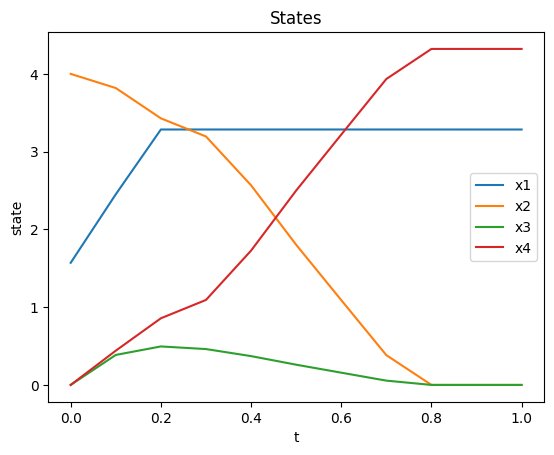

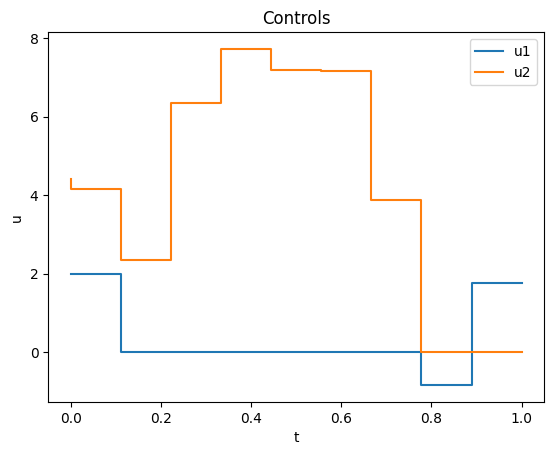

In [27]:
# solve_my_ocp_problem_tpl.py
from admiser.examples.my_free_terminal_time import problem, N, dt

def main():
    solver = OCPSolver(problem)
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt  = res["U_opt"]              # shape = (N*nu,)
    theta  = res.get("theta_opt", None)
    J_opt  = res["J_opt"]
    X_opt  = res["X_opt"]              # shape = (N+1, nx)
    t_opt  = res["t_opt"]              # shape = (N+1,)
    eq_res = res.get("eq_resid", None)   # equality residual G(z), should be ~ 0
    in_res = res.get("ineq_resid", None) # inequality residual C(z), should be >= 0

    print("\n=== results ===")
    print("J* =", J_opt)
    if theta is not None:
        print("theta* =", theta)
    if eq_res is not None:
        print("eq residual:", eq_res)
    if in_res is not None:
        print("ineq residual:", in_res)

    # states
    plt.figure()
    for i in range(X_opt.shape[1]):
        plt.plot(t_opt, X_opt[:, i], label=f"x{i+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend()

    # controls: piecewise constant over N segments; reshape the flat U_opt
    nu = problem.nu
    U_mat = U_opt.reshape(N, nu) if U_opt.ndim == 1 else U_opt
    tc = np.linspace(0.0, np.sum(np.diff(t_opt)), N)  # equals linspace(0, T, N) for constant dt
    plt.figure()
    for j in range(nu):
        plt.step(tc, U_mat[:, j], where='pre', label=f"u{j+1}")
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


## From Teo CPET

Optimization terminated successfully    (Exit mode 0)
            Current function value: 46.17131126128508
            Iterations: 117
            Function evaluations: 299
            Gradient evaluations: 116

=== results ===
J* = 46.17131126128508


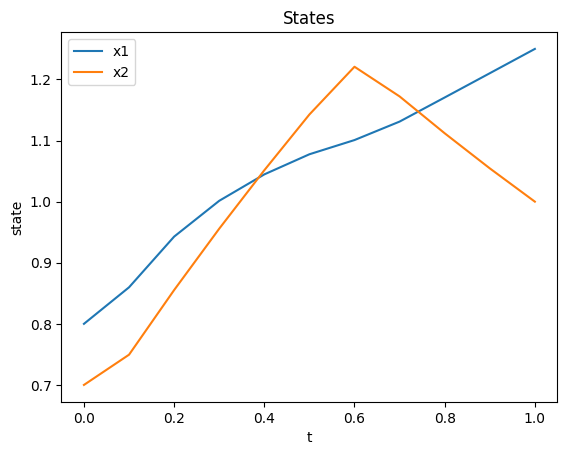

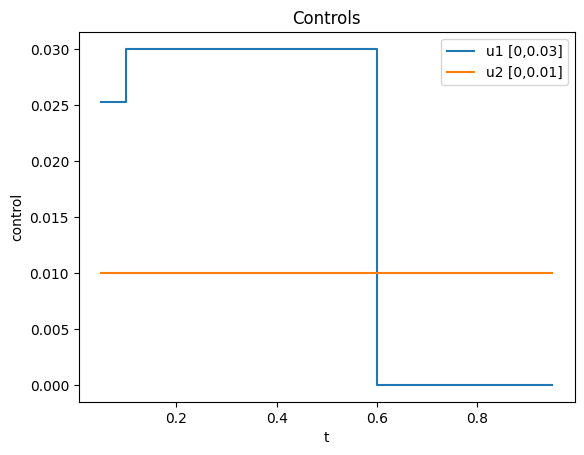

In [28]:
# solve_ratio_control.py
from admiser.examples.my_free_terminal_time2 import problem, N, dt, T

def main():
    solver = OCPSolver(problem)
    res = solver.solve(maxiter=3000, ftol=1e-6, disp=True)

    U_opt = res["U_opt"]          # (N*nu,)
    X_opt = res["X_opt"]          # (N+1, nx)
    t_opt = res["t_opt"]          # (N+1,)
    J_opt = res["J_opt"]
    term  = res.get("term_err", None)

    print("\n=== results ===")
    print(f"J* = {J_opt}")
    if term is not None:
        print("terminal eq residuals:", term)

    # state trajectories
    plt.figure()
    plt.plot(t_opt, X_opt[:,0], label="x1")
    plt.plot(t_opt, X_opt[:,1], label="x2")
    # plt.plot(t_opt, X_opt[:,2], label="x3")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("States"); plt.legend()

    # controls (step plot)
    U_mat = U_opt.reshape(N, 3)
    u1 = U_mat[:,0]; u2 = U_mat[:,1]; u3 = U_mat[:,2]
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt

    plt.figure()
    plt.step(tc, u1, where="mid", label="u1 [0,0.03]")
    plt.step(tc, u2, where="mid", label="u2 [0,0.01]")
    # plt.step(tc, u3, where="mid", label="u3 ≥ 0")
    plt.xlabel("t"); plt.ylabel("control"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


# complicate problem

## Two drugs cancer

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 2372828.6534871734
            Iterations: 6
            Function evaluations: 2
            Gradient evaluations: 2

=== results ===
J* = 2372828.6534871734
ineq residual: [-2.15965775e-03  1.00000000e-08]


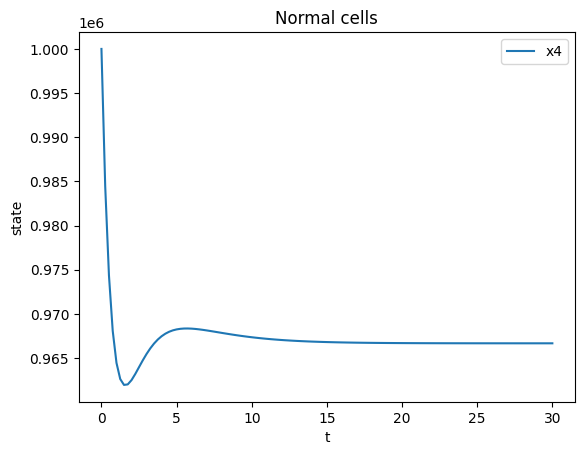

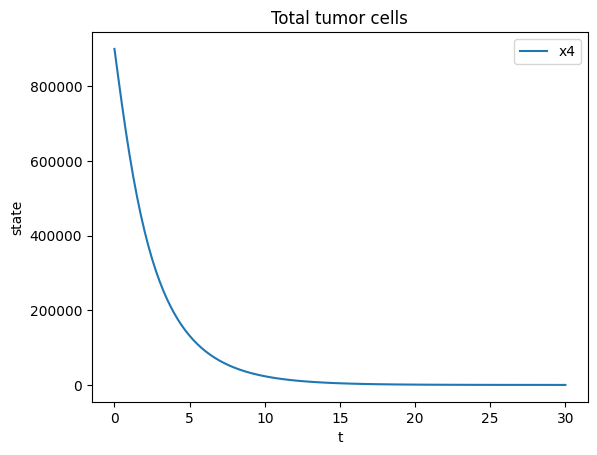

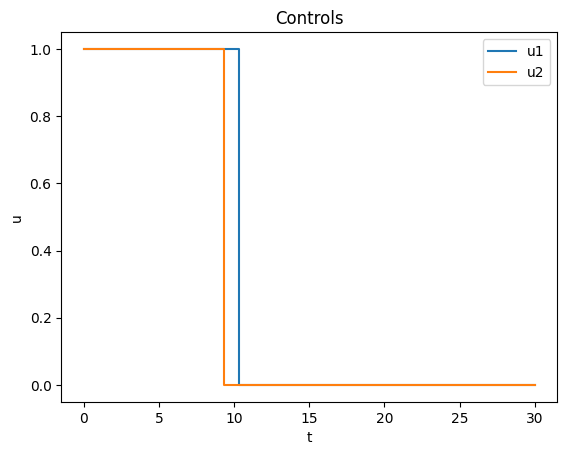

In [29]:
# solve_my_ocp_problem_tpl.py
from admiser.examples.my_medical1 import problem, N, dt

def main():
    solver = OCPSolver(problem)
    res = solver.solve(maxiter=2000, ftol=1e-9, disp=True)

    U_opt  = res["U_opt"]              # shape = (N*nu,)
    theta  = res.get("theta_opt", None)
    J_opt  = res["J_opt"]
    X_opt  = res["X_opt"]              # shape = (N+1, nx)
    t_opt  = res["t_opt"]              # shape = (N+1,)
    eq_res = res.get("eq_resid", None)   # equality residual G(z), should be ~ 0
    in_res = res.get("ineq_resid", None) # inequality residual C(z), should be >= 0

    print("\n=== results ===")
    print("J* =", J_opt)
    if theta is not None:
        print("theta* =", theta)
    if eq_res is not None:
        print("eq residual:", eq_res)
    if in_res is not None:
        print("ineq residual:", in_res)

    # states
    plt.figure()
    plt.plot(t_opt, X_opt[:, 3], label=f"x{3+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("Normal cells"); plt.legend()

    plt.figure()
    plt.plot(t_opt, X_opt[:, 0] + X_opt[:, 1] + X_opt[:, 2], label=f"x{3+1}")
    plt.xlabel("t"); plt.ylabel("state"); plt.title("Total tumor cells"); plt.legend()

    # controls: piecewise constant over N segments; reshape the flat U_opt
    nu = problem.nu
    U_mat = U_opt.reshape(N, nu) if U_opt.ndim == 1 else U_opt
    tc = np.linspace(0.0, np.sum(np.diff(t_opt)), N)  # equals linspace(0, T, N) for constant dt
    plt.figure()
    for j in range(nu):
        plt.step(tc, U_mat[:, j], where='pre', label=f"u{j+1}")
    plt.xlabel("t"); plt.ylabel("u"); plt.title("Controls"); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()


## SRI

Optimization terminated successfully    (Exit mode 0)
            Current function value: 310.2930509635074
            Iterations: 70
            Function evaluations: 216
            Gradient evaluations: 68

=== results ===
J* = 310.2930509635074
ineq residual(s): [-1.70161552e-09 -5.32952914e-07]

Estimated ∫ u1*S dt = 0.3864 (budget ≤ 0.6)


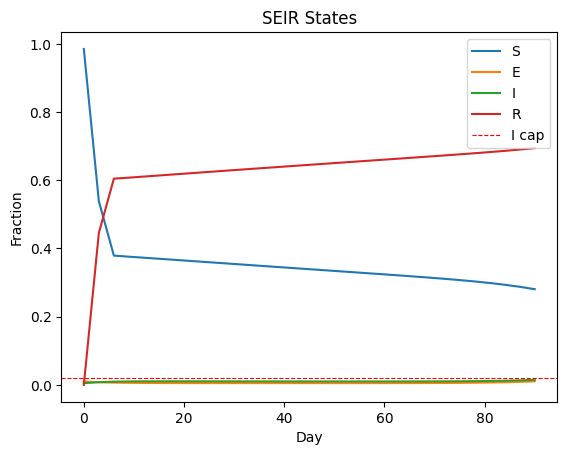

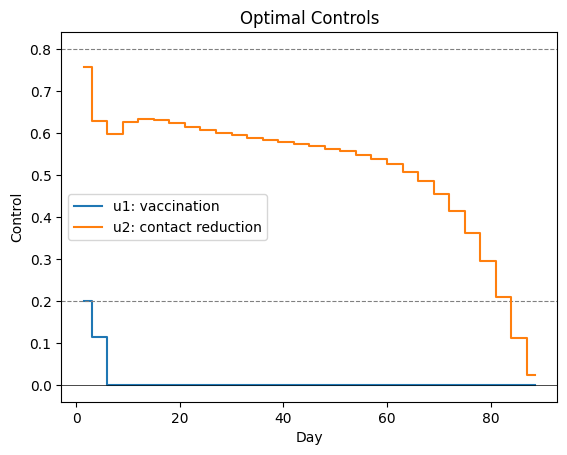

In [30]:
# solve_covid_seir_ocp.py
from admiser.examples.my_medical2 import problem, N, dt, T, u1_max, u2_max, I_cap, V_budget

def main():
    solver = OCPSolver(problem)
    res = solver.solve(maxiter=3000, ftol=1e-6, disp=True)

    print("\n=== results ===")
    print("J* =", res["J_opt"])
    if "term_err" in res and res["term_err"] is not None:
        print("eq residual:", res["term_err"])
    if "ineq_resid" in res and res["ineq_resid"] is not None:
        print("ineq residual(s):", res["ineq_resid"])

    U  = res["U_opt"].reshape(N, -1)   # (N,2)
    t  = res["t_opt"]
    X  = res["X_opt"]                  # (N+1,4): [S,E,I,R]
    S,E,I,R = X[:,0], X[:,1], X[:,2], X[:,3]

    # --- states ---
    plt.figure()
    plt.plot(t, S, label="S")
    plt.plot(t, E, label="E")
    plt.plot(t, I, label="I")
    plt.plot(t, R, label="R")
    plt.axhline(I_cap, color='r', ls='--', lw=0.8, label="I cap")
    plt.xlabel("Day"); plt.ylabel("Fraction")
    plt.title("SEIR States")
    plt.legend()

    # --- controls ---
    tc = np.linspace(0.0, T, N, endpoint=False) + 0.5*dt
    plt.figure()
    plt.step(tc, U[:,0], where='mid', label="u1: vaccination")
    plt.axhline(0.0, color='k', lw=0.5)
    plt.axhline(u1_max, color='gray', ls='--', lw=0.8)
    plt.step(tc, U[:,1], where='mid', label="u2: contact reduction")
    plt.axhline(u2_max, color='gray', ls='--', lw=0.8)
    plt.xlabel("Day"); plt.ylabel("Control")
    plt.title("Optimal Controls")
    plt.legend()

    # --- cumulative vaccine usage, approximating int u1*S dt ---
    v_consumed = np.trapezoid(U[:,0] * 0.5*(S[:-1] + S[1:]), dx=dt)
    print(f"\nEstimated ∫ u1*S dt = {v_consumed:.4f} (budget ≤ {V_budget})")

    plt.show()

if __name__ == "__main__":
    main()


### TODO - Problem Scale, Time Scaling
- linear growth condition, Lipschitz condition, existence and uniqueness of the solution